<a href="https://colab.research.google.com/github/srijakothakonda/creditcard_Fraud-detection/blob/main/credit_card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

2. Load Dataset

In [ ]:
import pandas as pd

data = pd.read_csv("/content/creditcard.csv")

print(data.shape)
print(data.isnull().sum().sum())

(284807, 31)
0


3. Dataset Information

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


4. Class Distribution Analysis

In [ ]:
print(data['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [ ]:
fraud_percentage = (
    data['Class'].sum() / len(data)
) * 100

print("Fraud Percentage:", fraud_percentage)

Fraud Percentage: 0.1727485630620034


5. Visualize Class Distribution

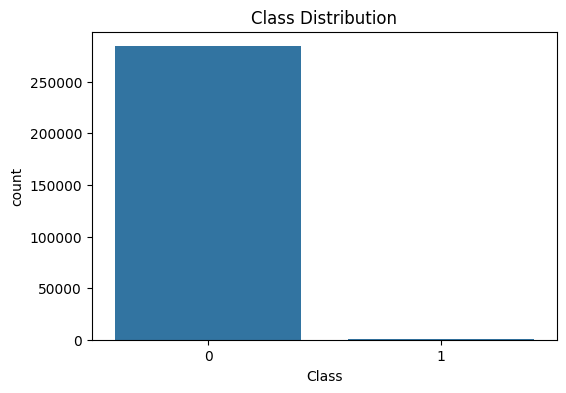

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Class',
    data=data
)

plt.title("Class Distribution")

plt.show()

6. Separate Features and Target

In [ ]:
X = data.drop('Class', axis=1)

y = data['Class']

7. Feature Scaling

In [ ]:
scaler = StandardScaler()

X['Time'] = scaler.fit_transform(
    X[['Time']]
)

X['Amount'] = scaler.fit_transform(
    X[['Amount']]
)

8. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

9. Apply SMOTE

In [ ]:
print("Before SMOTE")

print(y_train.value_counts())
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = (
    smote.fit_resample(
        X_train,
        y_train
    )
)
print("After SMOTE")

print(
    pd.Series(
        y_train_smote
    ).value_counts()
)

Before SMOTE
Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE
Class
0    227451
1    227451
Name: count, dtype: int64


10. Build Random Forest Model

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

model = ExtraTreesClassifier(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_smote, y_train_smote)

print("Model Trained Successfully")

Model Trained Successfully


11. Make Predictions

In [ ]:
y_pred = model.predict(
    X_test
)

12. Calculate Accuracy

In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    accuracy
)

Accuracy: 0.9995084442259752


13. Confusion Matrix

[[56852    12]
 [   16    82]]


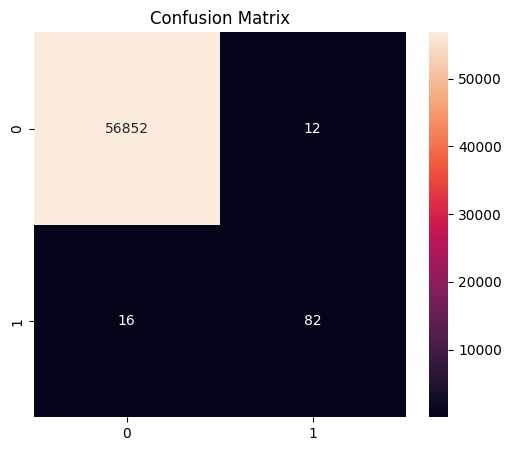

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Confusion Matrix"
)

plt.show()

14. Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



15. ROC-AUC Score

In [ ]:
y_prob = model.predict_proba(
    X_test
)[:,1]

roc = roc_auc_score(
    y_test,
    y_prob
)

print(
    "ROC-AUC:",
    roc
)

ROC-AUC: 0.9559129803440791


16. ROC Curve

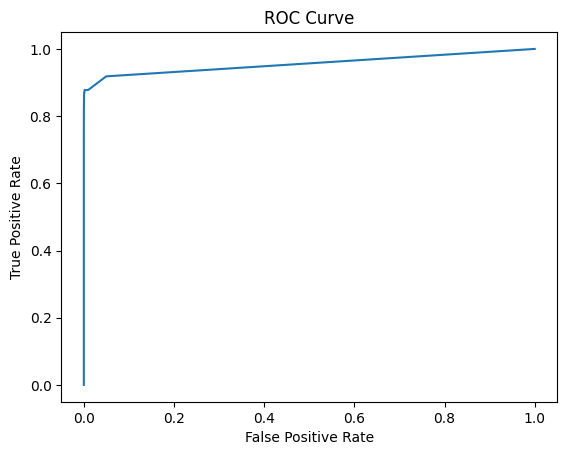

In [ ]:
fpr, tpr, threshold = roc_curve(
    y_test,
    y_prob
)
plt.plot(
    fpr,
    tpr
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.show()

17. Feature Importance

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(
    importance.head(10)
)

   Feature  Importance
4       V4    0.163407
14     V14    0.125266
12     V12    0.105924
16     V16    0.096172
17     V17    0.080955
3       V3    0.069250
10     V10    0.056668
11     V11    0.053198
18     V18    0.037916
19     V19    0.024204


18. Sample Prediction

In [ ]:
sample = X_test.iloc[0].values.reshape(
    1,
    -1
)
prediction = model.predict(
    sample
)
if prediction[0] == 0:
    print(
        "Legitimate Transaction"
    )
else:
    print(
        "Fraudulent Transaction"
    )

Legitimate Transaction


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(


In [ ]:
print("Dataset Shape:", data.shape)

print("NaN values in Class:", data['Class'].isnull().sum())

print("Unique values in Class:")
print(data['Class'].unique())

print("Data type of Class:")
print(data['Class'].dtype)

Dataset Shape: (284807, 31)
NaN values in Class: 0
Unique values in Class:
[0 1]
Data type of Class:
int64


In [ ]:
data = data.dropna(subset=['Class'])

print(data.shape)
print(data['Class'].isnull().sum())

(284807, 31)
0


In [ ]:
X = data.drop('Class', axis=1)
y = data['Class']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)